<a href="https://colab.research.google.com/github/AjaySreekumar47/vlm-research/blob/main/seem_exp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/UX-Decoder/Segment-Everything-Everywhere-All-At-Once.git
%cd Segment-Everything-Everywhere-All-At-Once

Cloning into 'Segment-Everything-Everywhere-All-At-Once'...
remote: Enumerating objects: 1127, done.
remote: Counting objects: 100% (357/357), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 1127 (delta 297), reused 278 (delta 278), pack-reused 770 (from 2)
Receiving objects: 100% (1127/1127), 303.82 MiB | 41.08 MiB/s, done.
Resolving deltas: 100% (492/492), done.
/content/Segment-Everything-Everywhere-All-At-Once


In [2]:
import sys
sys.version

'3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]'

In [ ]:
!cat /content/Segment-Everything-Everywhere-All-At-Once/assets/requirements/requirements.txt

In [ ]:
!cat /content/Segment-Everything-Everywhere-All-At-Once/assets/requirements/requirements_custom.txt

In [5]:
%%writefile /content/Segment-Everything-Everywhere-All-At-Once/assets/requirements/requirements_colab.txt
# Core — PyTorch (match these two exactly)
torch==2.4.1
torchvision==0.19.1

# Scientific stack
numpy>=2.0.0,<3
pandas>=2.2.2
scikit-learn>=1.5.1
scikit-image>=0.24.0
pyarrow>=15.0.2

# Imaging / CV
pillow>=10.3.0
opencv-python>=4.10.0.84
kornia>=0.7.2
timm>=0.9.16
einops>=0.7.0
fvcore>=0.1.5.post20221221
pycocotools>=2.0.8
shapely>=2.0.4

# NLP / HF
transformers>=4.41.2
accelerate>=0.29.3
sentencepiece>=0.2.0
ftfy>=6.2.0
regex>=2023.12.25
nltk>=3.8.1

# Utils / config
pyyaml>=6.0.1
json_tricks>=3.17.3
yacs>=0.1.8
cython>=3.0.10

# Datasets / eval
vision-datasets>=0.2.2
cityscapesscripts>=2.2.2
diffdist==0.1
mup==1.0.0
mpi4py>=3.1.5

# Logging / UI
wandb>=0.16.6
gradio>=3.50.2

# Known-to-build but niche
infinibatch==0.1.1

# ---- Optional / caution on Py3.12 & Colab CUDA ----
# deepspeed==0.14.2   # Only if a wheel exists for your CUDA; otherwise omit

Writing /content/Segment-Everything-Everywhere-All-At-Once/assets/requirements/requirements_colab.txt


In [ ]:
# Pick the CUDA index that matches your runtime (cu121 is common on Colab in 2025)
!pip install --upgrade pip
!pip install --index-url https://download.pytorch.org/whl/cu121 torch==2.4.1 torchvision==0.19.1

# Then install the rest from your updated requirements.txt
!pip install -r /content/Segment-Everything-Everywhere-All-At-Once/assets/requirements/requirements_colab.txt

In [9]:
!pip uninstall -y torchaudio
# (keep your existing torch==2.4.1 / torchvision==0.19.1)

In [ ]:
!pip install -U einops==0.8.1

In [ ]:
!pip install -U 'cython>=3.0' pycocotools 'fvcore>=0.1.5' 'iopath>=0.1.10'

In [ ]:
# Build against your current torch/cuda; --no-build-isolation helps reuse your env
!pip install --no-build-isolation 'git+https://github.com/MaureenZOU/detectron2-xyz.git'

In [ ]:
!sudo apt-get update && sudo apt-get install -y ffmpeg
!pip install -U openai-whisper

In [ ]:
!apt-get install tree
!tree -L 10

In [15]:
CKPT="/content/drive/MyDrive/Endo2017/seem_focall_v0.pt"

In [ ]:
%cd /content/Segment-Everything-Everywhere-All-At-Once
!pip install -U pip setuptools wheel ninja

In [1]:
# build the deformable attention op used by the encoder
%cd /content/Segment-Everything-Everywhere-All-At-Once/modeling/vision/encoder/ops
!bash make.sh || true
!python setup.py build_ext --inplace
!pip install .
%cd /content/Segment-Everything-Everywhere-All-At-Once

/content/Segment-Everything-Everywhere-All-At-Once/modeling/vision/encoder/ops
running build
running build_py
creating build/lib.linux-x86_64-cpython-312/modules
copying modules/ms_deform_attn.py -> build/lib.linux-x86_64-cpython-312/modules
copying modules/__init__.py -> build/lib.linux-x86_64-cpython-312/modules
creating build/lib.linux-x86_64-cpython-312/functions
copying functions/__init__.py -> build/lib.linux-x86_64-cpython-312/functions
copying functions/ms_deform_attn_func.py -> build/lib.linux-x86_64-cpython-312/functions
running build_ext
/usr/local/lib/python3.12/dist-packages/torch/utils/cpp_extension.py:414: UserWarning: The detected CUDA version (12.5) has a minor version mismatch with the version that was used to compile PyTorch (12.1). Most likely this shouldn't be a problem.
  warnings.warn(CUDA_MISMATCH_WARN.format(cuda_str_version, torch.version.cuda))
/usr/local/lib/python3.12/dist-packages/torch/utils/cpp_extension.py:424: UserWarning: There are no x86_64-linux-gnu

In [2]:
# define paths in Python
IMG = "inference/images/street.jpg"
OUTDIR = "/content/outputs"
CKPT = "/content/drive/MyDrive/Endo2017/seem_focall_v0.pt"

# make directory (shell)
!mkdir -p /content/outputs

import sys, os
sys.path.append("/content/Segment-Everything-Everywhere-All-At-Once")

In [ ]:
# Back to a Py3.12-friendly Pillow
!pip install -U "pillow>=10.3.0,<11"

In [1]:
import pathlib, re, textwrap

p = pathlib.Path("/content/Segment-Everything-Everywhere-All-At-Once/inference/xdecoder/infer_semseg.py")
src = p.read_text()

# 1) Use Cityscapes-19-style classes for street scenes
cityscapes19 = [
  'road','sidewalk','building','wall','fence','pole','traffic light','traffic sign',
  'vegetation','terrain','sky','person','rider','car','truck','bus','train','motorcycle','bicycle'
]
src = re.sub(r"stuff_classes\s*=\s*\[.*?\]",
             "stuff_classes = " + repr(cityscapes19),
             src, flags=re.S)

# 2) Avoid reusing the 'demo' dataset name (prevents catalog collisions)
src = src.replace('MetadataCatalog.get("demo")', 'MetadataCatalog.get("street_demo")')
src = src.replace("MetadataCatalog.get('demo')", "MetadataCatalog.get('street_demo')")

# 3) Numpy 2.x compatibility (np.int → int) if not already patched
src = src.replace("astype(np.int)", "astype(int)")

# 4) Ensure thing_* keys exist so Visualizer doesn't error
if "thing_dataset_id_to_contiguous_id" not in src:
    src = re.sub(
        r'MetadataCatalog\.get\("street_demo"\)\.set\(\s*stuff_colors=stuff_colors,\s*stuff_classes=stuff_classes,\s*stuff_dataset_id_to_contiguous_id=stuff_dataset_id_to_contiguous_id,\s*\)',
        'MetadataCatalog.get("street_demo").set(\n'
        '    stuff_colors=stuff_colors,\n'
        '    stuff_classes=stuff_classes,\n'
        '    stuff_dataset_id_to_contiguous_id=stuff_dataset_id_to_contiguous_id,\n'
        '    thing_colors=[],\n'
        '    thing_classes=[],\n'
        '    thing_dataset_id_to_contiguous_id={}\n'
        ')',
        src, flags=re.S
    )

p.write_text(src)
print("Patched:", p)

Patched: /content/Segment-Everything-Everywhere-All-At-Once/inference/xdecoder/infer_semseg.py


In [2]:
%cd /content/Segment-Everything-Everywhere-All-At-Once/modeling/vision/encoder/ops
!pip install -U ninja setuptools wheel
!bash make.sh || true
!python setup.py build_ext --inplace
!pip install .
%cd /content/Segment-Everything-Everywhere-All-At-Once


/content/Segment-Everything-Everywhere-All-At-Once/modeling/vision/encoder/ops
running build
running build_py
copying modules/ms_deform_attn.py -> build/lib.linux-x86_64-cpython-312/modules
copying modules/__init__.py -> build/lib.linux-x86_64-cpython-312/modules
copying functions/__init__.py -> build/lib.linux-x86_64-cpython-312/functions
copying functions/ms_deform_attn_func.py -> build/lib.linux-x86_64-cpython-312/functions
running build_ext
/usr/local/lib/python3.12/dist-packages/torch/utils/cpp_extension.py:414: UserWarning: The detected CUDA version (12.5) has a minor version mismatch with the version that was used to compile PyTorch (12.1). Most likely this shouldn't be a problem.
  warnings.warn(CUDA_MISMATCH_WARN.format(cuda_str_version, torch.version.cuda))
/usr/local/lib/python3.12/dist-packages/torch/utils/cpp_extension.py:424: UserWarning: There are no x86_64-linux-gnu-g++ version bounds defined for CUDA version 12.5
  warnings.warn(f'There are no {compiler_name} version b

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/content/Segment-Everything-Everywhere-All-At-Once/modeling/vision/encoder/ops/modules/ms_deform_attn.py:87: SyntaxWarning: invalid escape sequence '\s'
  :param input_flatten               (N, \sum_{l=0}^{L-1} H_l \cdot W_l, C)
/content/Segment-Everything-Everywhere-All-At-Once/modeling/vision/encoder/transformer_encoder_deform.py:317: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https:/

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

/content/Segment-Everything-Everywhere-All-At-Once/modeling/BaseModel.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(load_dir, map_location=sel

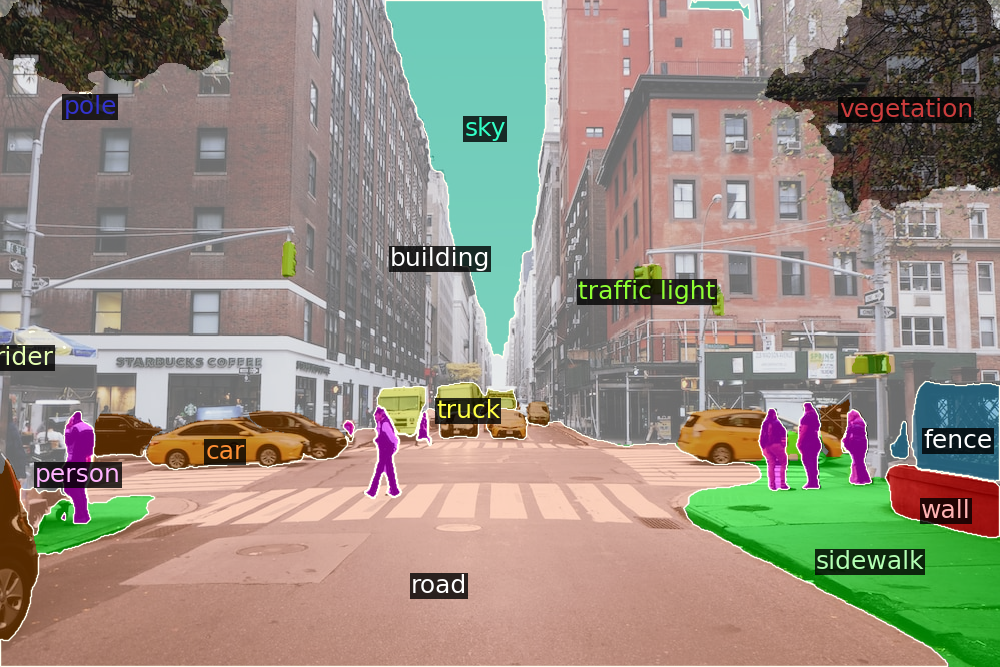

In [3]:
import sys, os, shutil
repo = "/content/Segment-Everything-Everywhere-All-At-Once"
sys.path.append(repo)
os.chdir(repo)

# Pillow shim for detectron2 on Pillow 10+
from PIL import Image
if not hasattr(Image, "LINEAR"):
    try:
        Image.LINEAR = Image.Resampling.BILINEAR
    except Exception:
        Image.LINEAR = Image.BILINEAR

# (optional) use your preferred input
shutil.copy("inference/images/street.jpg", "inference/images/animals.png")

from inference.xdecoder.infer_semseg import main as semseg_main
ckpt = "/content/drive/MyDrive/Endo2017/seem_focall_v0.pt"

args = [
    "evaluate",                                      # positional command FIRST
    "--conf_files", "configs/seem/focall_unicl_lang_v0.yaml",
    "--overrides", "RESUME_FROM", ckpt               # key value pair
]
semseg_main(args)

from PIL import Image as PILImage, ImageOps
display(ImageOps.contain(PILImage.open("output/sem.png"), (1000, 1000)))

## Final configuration (what worked)

- Python: 3.12.11 (Colab default)

- PyTorch/TV: torch==2.4.1, torchvision==0.19.1 (CUDA wheels)

- torchaudio: uninstalled (avoid mismatch)

- Key libs: einops==0.8.1, opencv-python>=4.10, pillow>=10, numpy>=2, pandas>=2.2.2, scikit-learn>=1.5.1, scikit-image>=0.24.0, timm>=0.9.16, fvcore, pycocotools, pyarrow>=15, kornia>=0.7.2, transformers>=4.41, accelerate>=0.29, ftfy, regex, sentencepiece, wandb, gradio

- Git deps: detectron2-xyz (built from source), openai-whisper (+ ffmpeg)

- SEEM repo: UX-Decoder/Segment-Everything-Everywhere-All-At-Once (cloned)

- Custom CUDA op: ms_deform_attn built via modeling/vision/encoder/ops

**Patches:**

- Pillow 10+: add Image.LINEAR shim at runtime

- NumPy 2.x: replace np.int → int

- infer_semseg.py:

  - switch animal labels → Cityscapes-19 street labels

  - add empty thing_* metadata keys

  - use unique dataset name street_demo (avoid catalog collisions)

  - (optional) we keep the script’s default input path; we copy your chosen image to that path before running